In [1]:
import time
from pathlib import Path

import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt

from demos.toys.datasets import generate_moons
from demos.toys.models import MLP
from demos.toys.tools import plot_ddpm_coefficients
from demos.toys.tools import plot_trajectory, set_seed
from demos.toys.tools import view_ddpm_trajectory

savedir = Path("./temp/noise")
savedir.mkdir(parents=True, exist_ok=True)

set_seed()

findfont: Failed to find font weight semibold, now using 700.


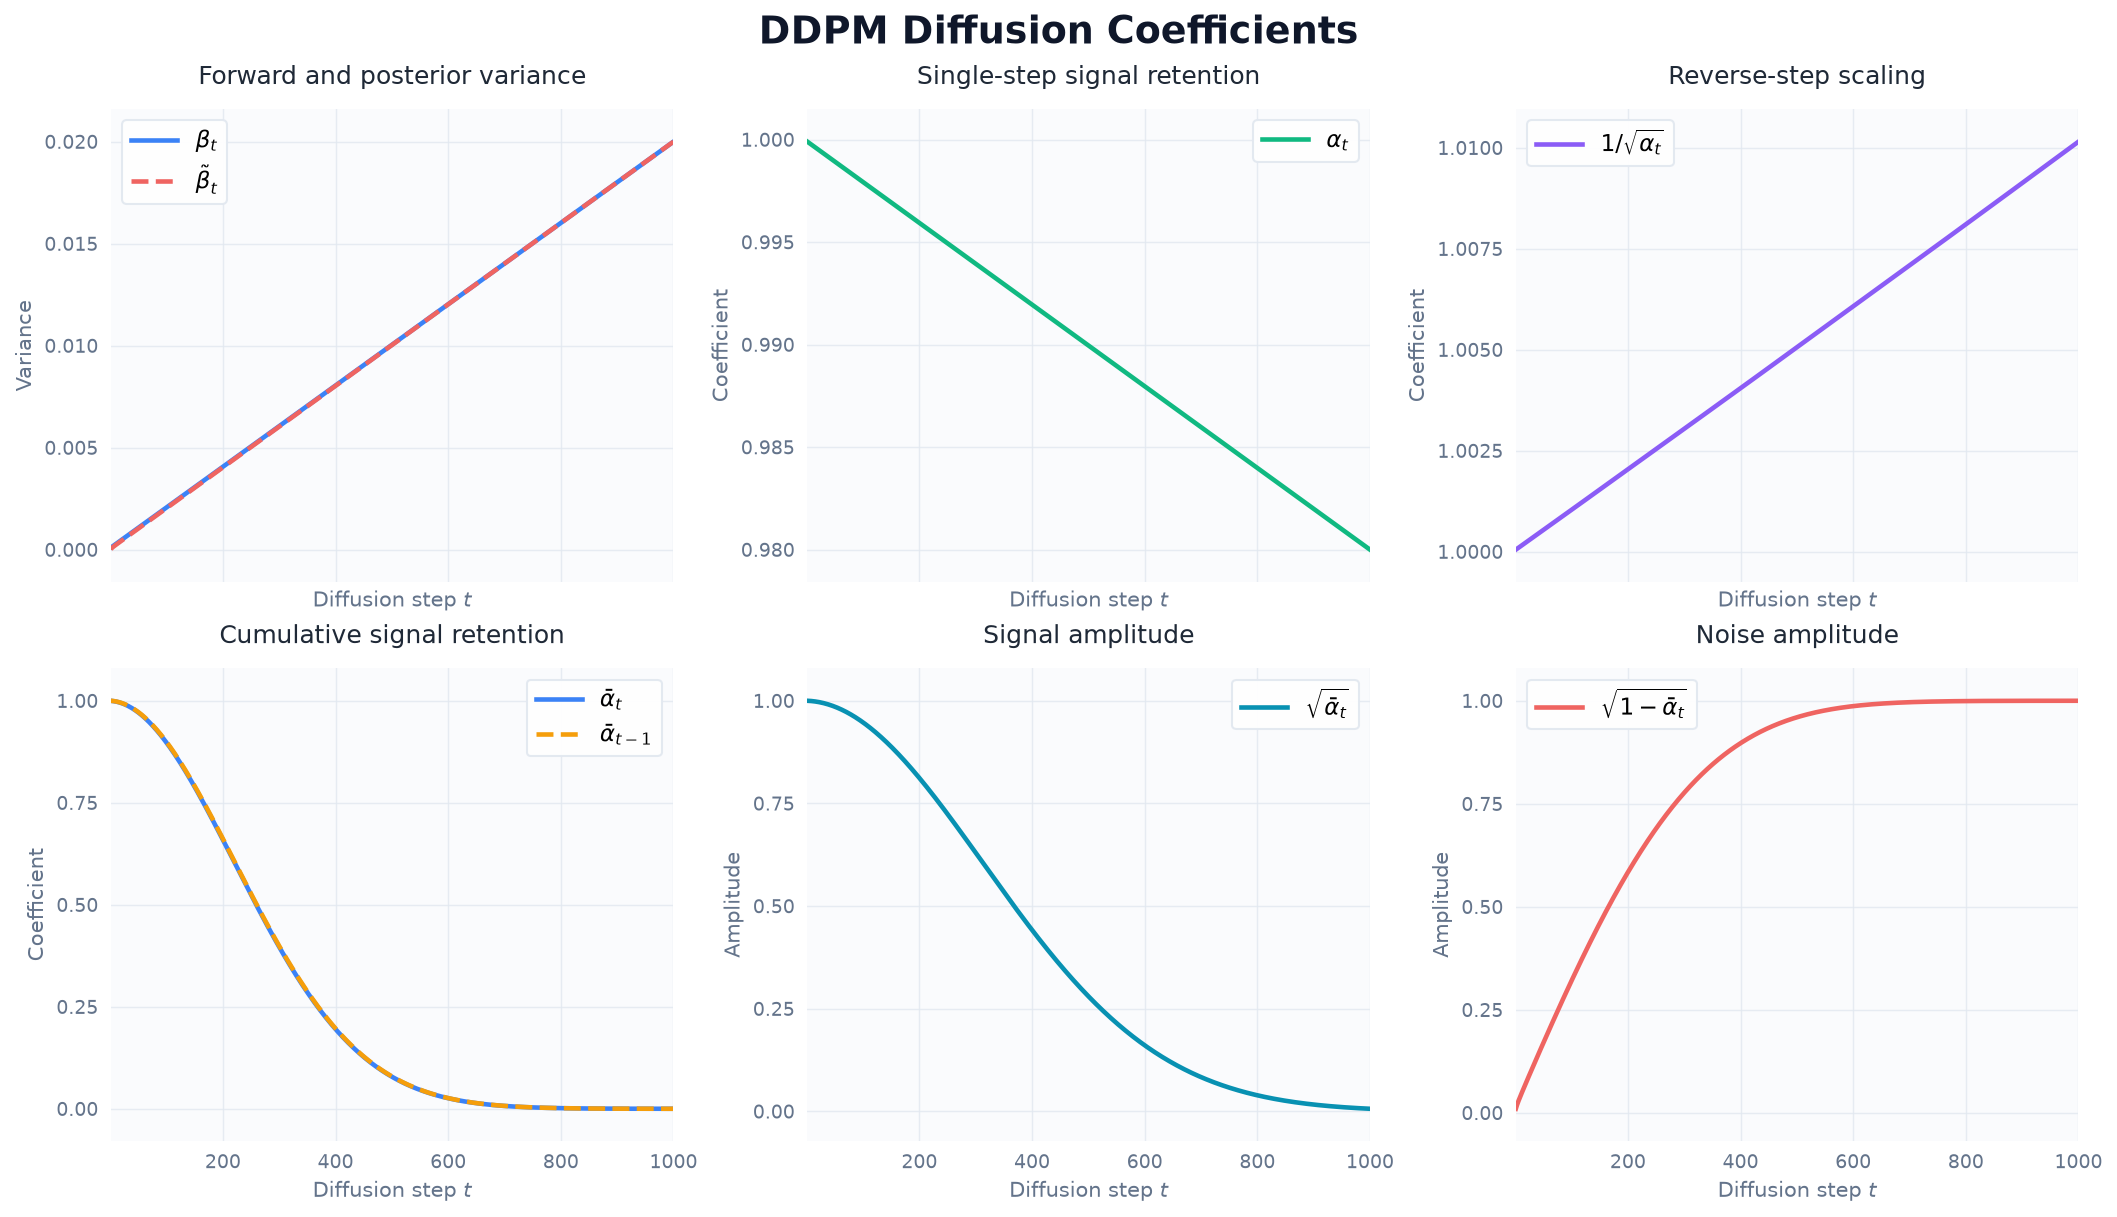

In [2]:
# ============================================================
# Hyperparameters
# ============================================================
batch_size = 256
dim = 2
T = 1000
K = 100000
save_every = 20000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# Diffusion coefficients
# ============================================================
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)  # \bar\alpha_t
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = alphas_cumprod.sqrt()
sqrt_one_minus_alphas_cumprod = (1.0 - alphas_cumprod).sqrt()
sqrt_recip_alphas = (1.0 / alphas).sqrt()

# Posterior variance  \beta_t * (1 - \bar\alpha_{t-1}) / (1 - \bar\alpha_t)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

plot_ddpm_coefficients(betas, alphas, alphas_cumprod, alphas_cumprod_prev, sqrt_alphas_cumprod,
                       sqrt_one_minus_alphas_cumprod, sqrt_recip_alphas, posterior_variance)

(<Figure size 750x750 with 1 Axes>, <Axes: >)

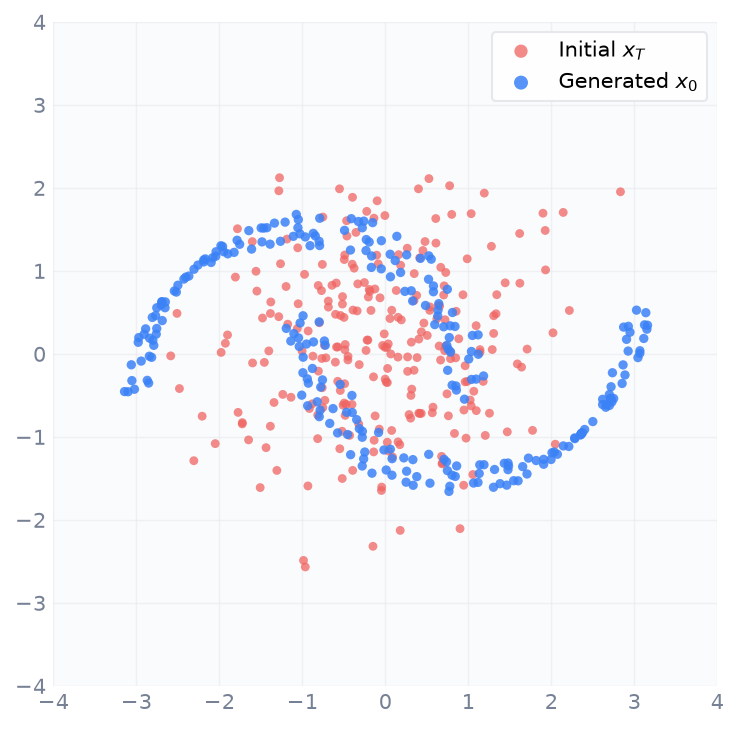

In [3]:
# Plot x0 and x1
x0, _ = generate_moons(batch_size)
x1 = torch.randn_like(x0)
plot_trajectory(x1, x0)

In [4]:
# ============================================================
# Forward diffusion  q(x_t | x_0)
# ============================================================
def q_sample(x0, t, noise):
    """x_t = sqrt(abar_t) * x0 + sqrt(1 - abar_t) * noise"""
    a = sqrt_alphas_cumprod[t].view(-1, 1)
    b = sqrt_one_minus_alphas_cumprod[t].view(-1, 1)
    return a * x0 + b * noise


## Predict Noise

The optimization objective function is expressed as：
$$\arg\min_\theta \frac{1}{2\sigma_q^2(t)}\frac{(1-\alpha_t)^2}{(1-\bar{\alpha}_t)\alpha_t}[\|
\epsilon_0 - \bar{\epsilon}_\theta(x_t,t)\|^2_2]$$

The mean of the generative process is expressed as:
$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}[x_t-\frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)] $$

And the generative process is expressed as:
$$x_{t-1}=\mu_\theta(x_t,t)+\sigma_t z_t, \qquad z_t= \begin{cases} \mathcal N(0,I),&t>1,\\ 0,&t=1. \end{cases} $$

In [5]:
# ============================================================
# Model
# ============================================================
model = MLP(dim=dim, time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# ============================================================
# Training
# ============================================================
start = time.time()
model.train()

for k in range(K):
    optimizer.zero_grad()

    x0, _ = generate_moons(batch_size)
    x0 = x0.to(device)

    t = torch.randint(0, T, (batch_size,), device=device)

    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)

    noise_pred = model(x_t, t)
    loss = F.mse_loss(noise_pred, noise)

    loss.backward()
    optimizer.step()

    step = k + 1

    if step % 1000 == 0:
        print(
            f"step {step:6d} | loss {loss.item():.4f} | "
            f"elapsed {time.time() - start:.1f}s"
        )

    if step % save_every == 0 or step == K:
        savepath = savedir / f"model_step_{step:06d}.pt"
        torch.save(model.state_dict(), savepath)
        print(f"Saved: {savepath}")

step   1000 | loss 0.5942 | elapsed 0.9s
step   2000 | loss 0.3116 | elapsed 1.8s
step   3000 | loss 0.3190 | elapsed 2.6s
step   4000 | loss 0.3559 | elapsed 3.4s
step   5000 | loss 0.3794 | elapsed 4.1s
step   6000 | loss 0.2826 | elapsed 4.9s
step   7000 | loss 0.3041 | elapsed 5.7s
step   8000 | loss 0.2895 | elapsed 6.5s
step   9000 | loss 0.3430 | elapsed 7.3s
step  10000 | loss 0.3509 | elapsed 8.1s
step  11000 | loss 0.2934 | elapsed 8.8s
step  12000 | loss 0.2658 | elapsed 9.6s
step  13000 | loss 0.2997 | elapsed 10.3s
step  14000 | loss 0.3430 | elapsed 11.1s
step  15000 | loss 0.2689 | elapsed 11.9s
step  16000 | loss 0.3663 | elapsed 12.6s
step  17000 | loss 0.3111 | elapsed 13.4s
step  18000 | loss 0.3102 | elapsed 14.2s
step  19000 | loss 0.3128 | elapsed 15.0s
step  20000 | loss 0.3098 | elapsed 15.7s
Saved: temp/noise/model_step_020000.pt
step  21000 | loss 0.2375 | elapsed 16.5s
step  22000 | loss 0.2802 | elapsed 17.3s
step  23000 | loss 0.3147 | elapsed 18.1s
step  2

In [6]:
# ============================================================
# Reverse sampling  p(x_{t-1} | x_t)
# ============================================================
@torch.no_grad()
def sample_ddpm_with_noise(model, x_init):
    model.eval()

    x = x_init.to(device).clone()
    n_samples = x.shape[0]
    trajectory = [x.clone()]

    for t_int in reversed(range(T)):
        t = torch.full(
            (n_samples,), t_int,
            device=device, dtype=torch.long,
        )
        eps = model(x, t)

        mean = sqrt_recip_alphas[t_int] * (
                x
                - betas[t_int]
                / sqrt_one_minus_alphas_cumprod[t_int]
                * eps
        )

        if t_int > 0:
            x = (
                    mean
                    + posterior_variance[t_int].sqrt()
                    * torch.randn_like(x)
            )
        else:
            x = mean

        trajectory.append(x.clone())

    return x, torch.stack(trajectory, dim=0)

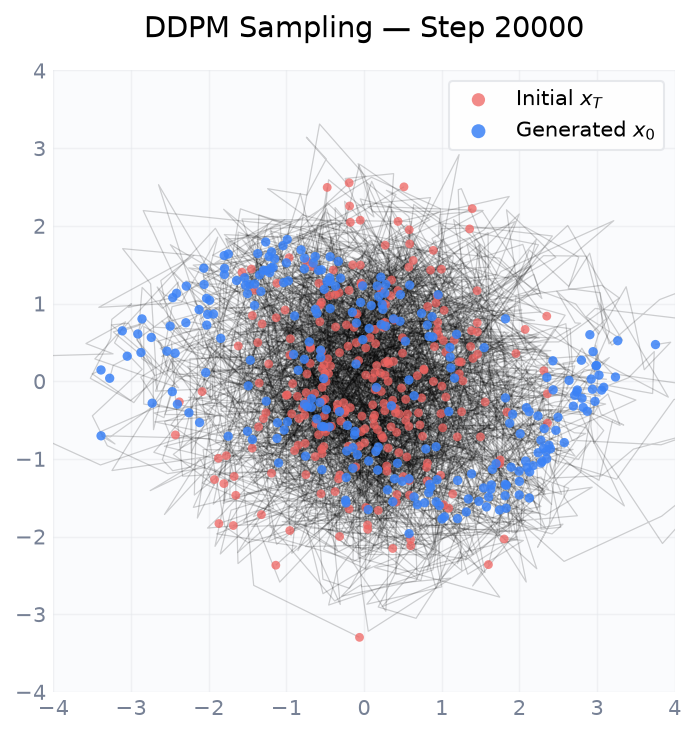

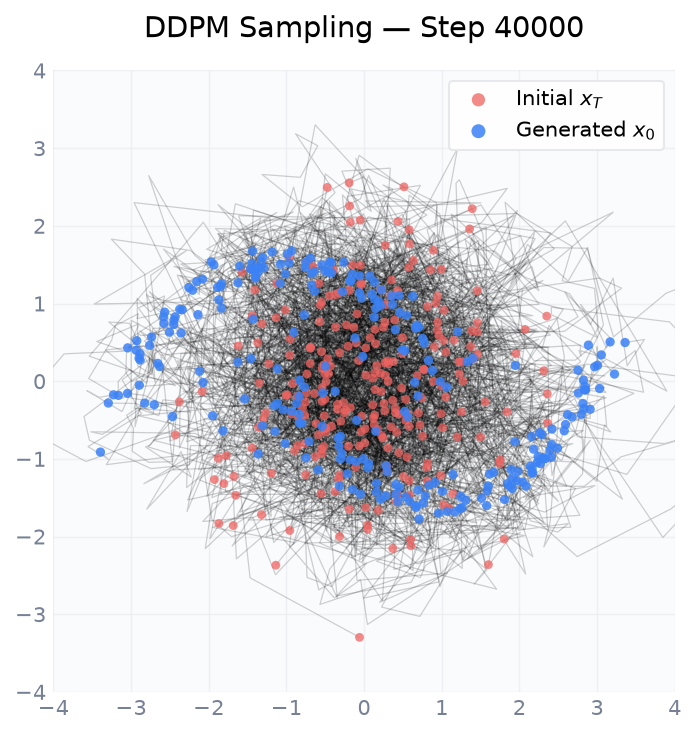

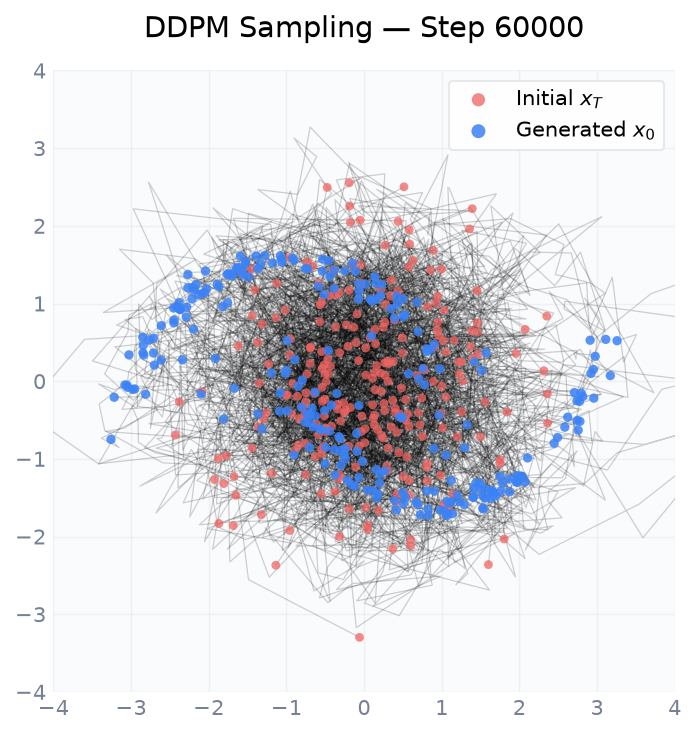

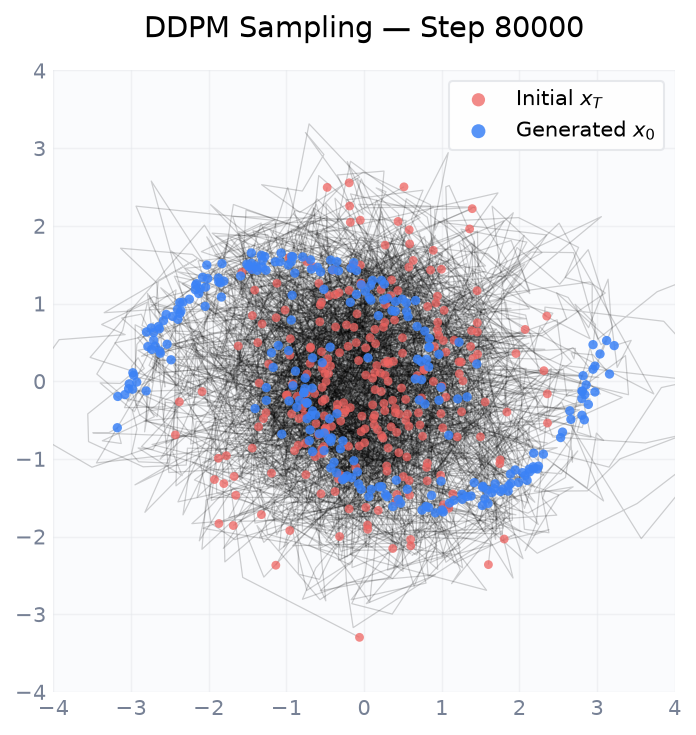

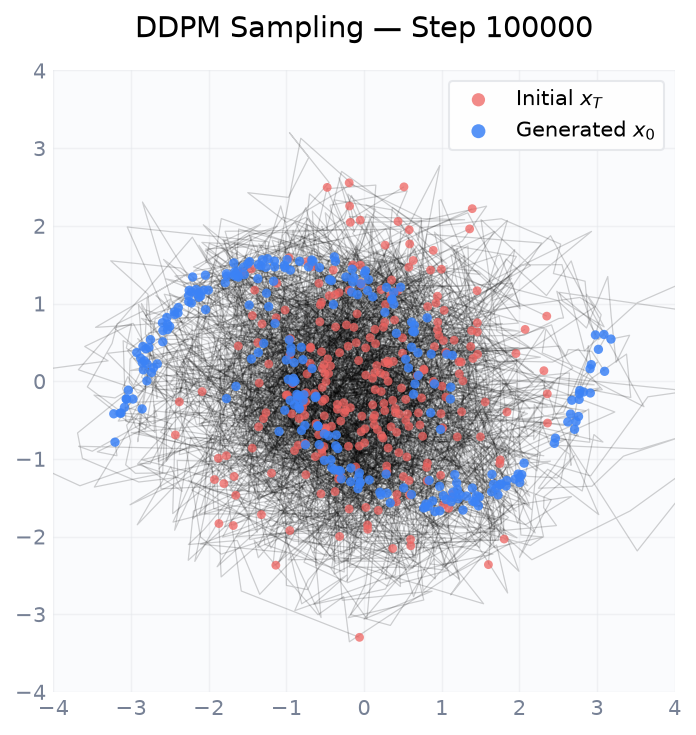

In [7]:
# 所有检查点使用同一批初始噪声
x1 = torch.randn(batch_size, dim, device=device)

# 包含定期保存的检查点和训练最后一步
steps = list(range(save_every, K + 1, save_every))
if K > 0 and (not steps or steps[-1] != K):
    steps.append(K)

for step in steps:
    set_seed()
    checkpoint = savedir / f"model_step_{step:06d}.pt"

    model.load_state_dict(
        torch.load(
            checkpoint,
            map_location=device,
            weights_only=True,
        )
    )
    model.to(device)

    samples, trajectory = sample_ddpm_with_noise(
        model,
        x_init=x1,
    )

    fig, ax = plot_trajectory(
        trajectory[0],
        samples,
        trajectory=trajectory,
        trajectory_interval=50,
        title=f"DDPM Sampling — Step {step}",
    )
    plt.show()

In [8]:
set_seed()
checkpoint = savedir / f"model_step_{K:06d}.pt"

model.load_state_dict(torch.load(
    checkpoint,
    map_location=device,
    weights_only=True,
)
)
model.to(device)

samples, trajectory = sample_ddpm_with_noise(
    model,
    x_init=x1,
)

view_ddpm_trajectory(trajectory)